# Atividade: Detecção de Fraudes
## Comparação entre Regressão Logística e Isolation Forest

In [1]:
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TEST_SIZE = 0.30
VALIDATION_SIZE = 0.25
PCA_COMPONENTS = 20

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'legend.frameon': True,
    'legend.framealpha': 0.95,
})

PALETTE = {
    'normal': '#2a9d8f',
    'fraude': '#d62828',
    'lr': '#2563eb',
    'if': '#dc2626',
    'pca': '#7c3aed',
    'neutral': '#475569',
}

---
## 1. Análise Exploratória

In [2]:
# Carregar dataset
df = pd.read_csv('creditcard.csv')

print(f'Dataset shape: {df.shape}')
print(f'Valores nulos: {df.isna().sum().sum()}')
print(f'Colunas: {df.columns.tolist()}')
df.head()

Dataset shape: (284807, 31)
Valores nulos: 0
Colunas: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# Distribuição de classes e nivel de desbalanceamento
class_counts = df['Class'].value_counts().sort_index()
class_rate = df['Class'].value_counts(normalize=True).sort_index()
fraud_rate = class_rate.loc[1]

summary_classes = pd.DataFrame({
    'Classe': ['Normal', 'Fraude'],
    'Quantidade': [class_counts.loc[0], class_counts.loc[1]],
    'Proporção': [class_rate.loc[0], class_rate.loc[1]],
})

print('Distribuição da variável alvo')
print(summary_classes.to_string(index=False, formatters={'Proporção': '{:.6%}'.format}))
print(f"\nTaxa real de fraude usada como referência para contamination: {fraud_rate:.6f}")
print(f"Acurácia ingênua ao prever tudo como normal: {class_rate.loc[0]:.4%}")
summary_classes

Distribuição da variável alvo
Classe  Quantidade  Propor??o
Normal      284315   0.998273
Fraude         492   0.001727

Taxa real de fraude usada como referência para contamination: 0.001727
Acurácia ingênua ao prever tudo como normal: 99.8273%


,Classe,Quantidade,Propor??o
0,Normal,284315,0.998273
1,Fraude,492,0.001727


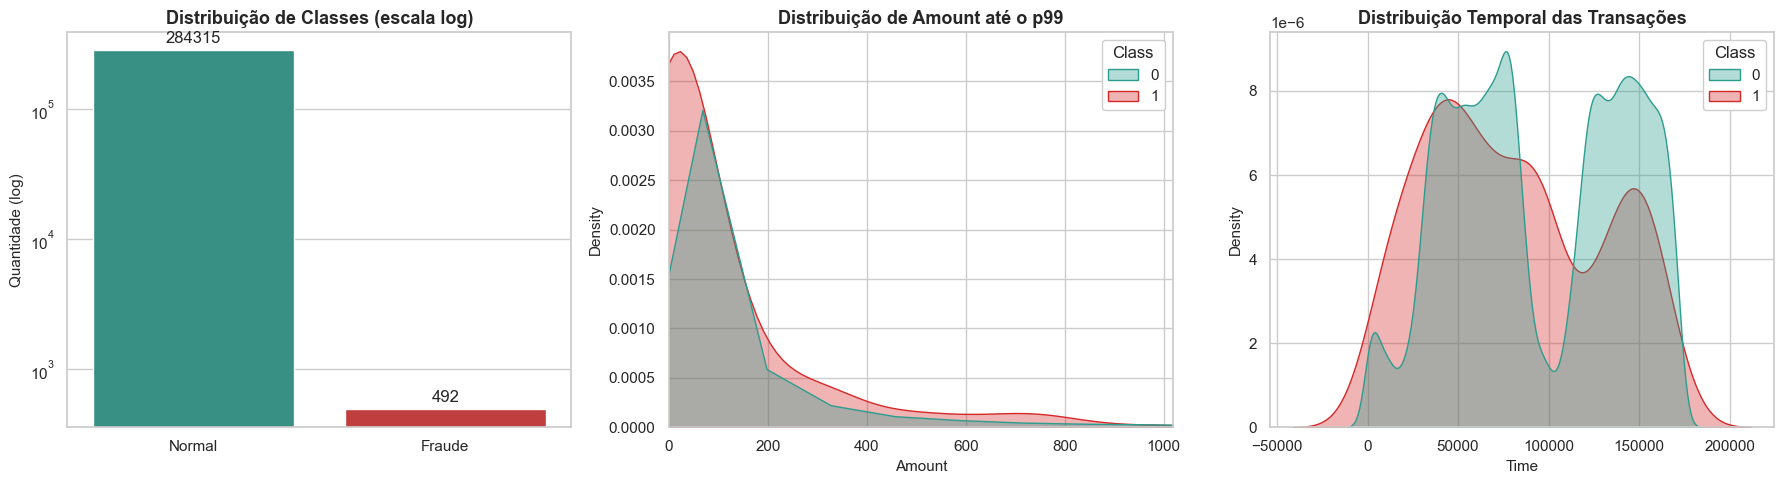

Insight: a base é extremamente desbalanceada. A acurácia isolada é enganosa porque um classificador que nunca detecta fraude já ultrapassa 99%.


In [6]:
# Visualizações da análise exploratória
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=summary_classes,
    x='Classe', y='Quantidade', hue='Classe',
    palette=[PALETTE['normal'], PALETTE['fraude']], ax=axes[0], legend=False
)
axes[0].set_yscale('log')
axes[0].set_title('Distribuição de Classes (escala log)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Quantidade (log)')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.0f', padding=3)

sns.kdeplot(data=df, x='Amount', hue='Class', common_norm=False, fill=True,
            palette=[PALETTE['normal'], PALETTE['fraude']], ax=axes[1], alpha=0.35)
axes[1].set_xlim(0, df['Amount'].quantile(0.99))
axes[1].set_title('Distribuição de Amount até o p99')
axes[1].set_xlabel('Amount')

sns.kdeplot(data=df, x='Time', hue='Class', common_norm=False, fill=True,
            palette=[PALETTE['normal'], PALETTE['fraude']], ax=axes[2], alpha=0.35)
axes[2].set_title('Distribuição Temporal das Transações')
axes[2].set_xlabel('Time')

plt.tight_layout()
plt.show()

print('Insight: a base é extremamente desbalanceada. A acurácia isolada é enganosa porque um classificador que nunca detecta fraude já ultrapassa 99%.')

In [7]:
# Estatísticas das features
feature_summary = df.drop(columns='Class').describe().T
feature_summary[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(3)

,mean,std,min,25%,50%,75%,max
Time,94813.86,47488.146,0.000,54201.500,84692.000,139320.500,172792.000
V1,0.00,1.959,-56.408,-0.920,0.018,1.316,2.455
V2,0.00,1.651,-72.716,-0.599,0.065,0.804,22.058
V3,-0.00,1.516,-48.326,-0.890,0.180,1.027,9.383
V4,0.00,1.416,-5.683,-0.849,-0.020,0.743,16.875
V5,0.00,1.380,-113.743,-0.692,-0.054,0.612,34.802
V6,0.00,1.332,-26.161,-0.768,-0.274,0.399,73.302
V7,-0.00,1.237,-43.557,-0.554,0.040,0.570,120.589
V8,0.00,1.194,-73.217,-0.209,0.022,0.327,20.007
V9,-0.00,1.099,-13.434,-0.643,-0.051,0.597,15.595


---
## 2. Preparação dos Dados

A padronização é ajustada apenas no treino e aplicada no teste. Isso evita vazamento de informação. Mesmo que as variáveis `V1` a `V28` já venham de uma transformação PCA do dataset original, `Time` e `Amount` não estão na mesma escala, então o `StandardScaler` é necessário para a Regressão Logística e também ajuda a tornar a comparação com PCA.

In [8]:
# Separar features e target
X = df.drop(columns='Class')
y = df['Class'].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'X_train: {X_train_scaled.shape} | fraudes: {y_train.sum()} ({y_train.mean():.4%})')
print(f'X_test:  {X_test_scaled.shape} | fraudes: {y_test.sum()} ({y_test.mean():.4%})')
print(f'Média do treino escalado: {X_train_scaled.mean():.6f} | desvio: {X_train_scaled.std():.6f}')

X_train: (199364, 30) | fraudes: 344 (0.1725%)
X_test:  (85443, 30) | fraudes: 148 (0.1732%)
Média do treino escalado: -0.000000 | desvio: 1.000000


In [9]:
# PCA ajustado exclusivamente no treino
pca = PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)
X_test_pca_2d = pca_2d.transform(X_test_scaled)

variance_explained = pca.explained_variance_ratio_.sum()
print(f'PCA com {PCA_COMPONENTS} componentes explica {variance_explained:.2%} da variância do treino.')
print(f'PCA 2D usado apenas para visualização explica {pca_2d.explained_variance_ratio_.sum():.2%}.')

PCA com 20 componentes explica 72.53% da variância do treino.
PCA 2D usado apenas para visualização explica 12.15%.


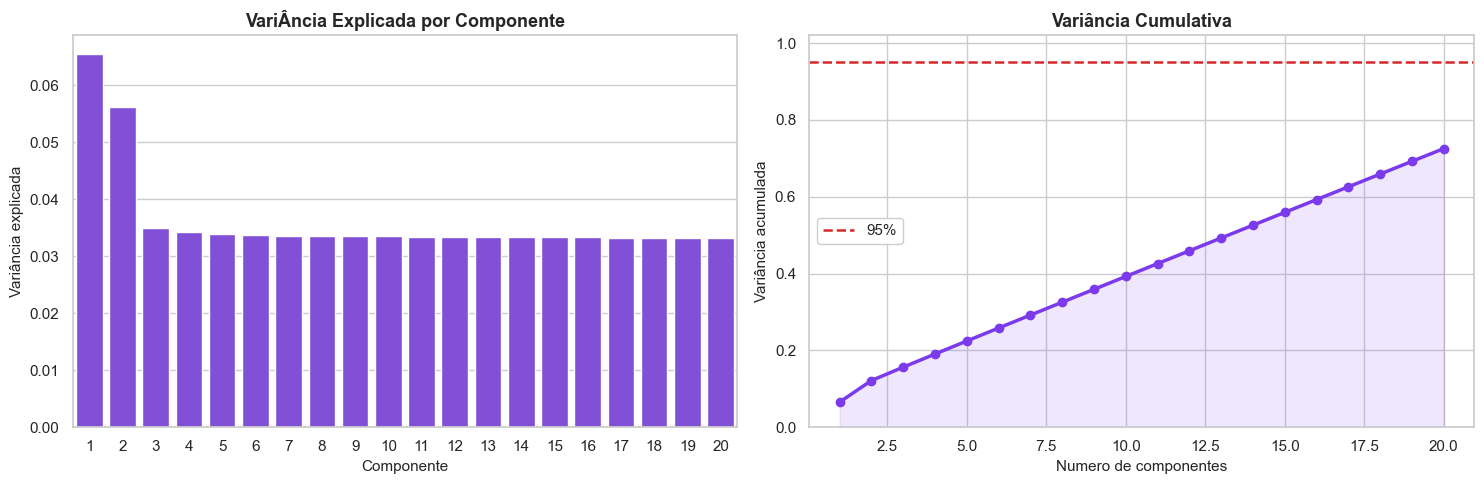

In [10]:
# Variância explicada pelo PCA
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
components = np.arange(1, PCA_COMPONENTS + 1)

sns.barplot(x=components, y=pca.explained_variance_ratio_, color=PALETTE['pca'], ax=axes[0])
axes[0].set_title('Variância Explicada por Componente')
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Variância explicada')
axes[0].tick_params(axis='x', rotation=0)

cumulative = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(components, cumulative, marker='o', linewidth=2.5, color=PALETTE['pca'])
axes[1].fill_between(components, cumulative, color=PALETTE['pca'], alpha=0.12)
axes[1].axhline(0.95, color=PALETTE['fraude'], linestyle='--', linewidth=1.8, label='95%')
axes[1].set_ylim(0, 1.02)
axes[1].set_title('Variância Cumulativa')
axes[1].set_xlabel('Numero de componentes')
axes[1].set_ylabel('Variância acumulada')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 3. Funções de Avaliação

A seleção de hiperparâmetros é feita em uma validação estratificada retirada do treino. Depois, o melhor conjunto é retreinado em todo o treino e avaliado uma única vez no teste. Isso evita escolher hiperparâmetros diretamente pelo teste.

In [14]:
def best_f1_threshold(y_true, scores):
    """Escolhe o threshold que maximiza F1 na validação; em empate, prioriza maior recall."""
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    if len(thresholds) == 0:
        return 0.5, 0.0

    precision_t = precision[:-1]
    recall_t = recall[:-1]
    f1_t = np.divide(
        2 * precision_t * recall_t,
        precision_t + recall_t,
        out=np.zeros_like(precision_t),
        where=(precision_t + recall_t) > 0,
    )
    candidates = np.flatnonzero(f1_t == f1_t.max())
    best_idx = candidates[np.argmax(recall_t[candidates])]
    return float(thresholds[best_idx]), float(f1_t[best_idx])


def metric_dict(y_true, y_pred, y_score, model, scenario, params, threshold=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        'Modelo': model,
        'Cenário': scenario,
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_score),
        'PR-AUC': average_precision_score(y_true, y_score),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'FPR': fp / (fp + tn) if (fp + tn) else 0,
        'FNR': fn / (fn + tp) if (fn + tp) else 0,
        'Threshold': threshold,
        'Parâmetros': params,
    }


def select_logistic_regression(X_train_data, y_train_data, scenario):
    X_fit, X_val, y_fit, y_val = train_test_split(
        X_train_data, y_train_data,
        test_size=VALIDATION_SIZE,
        stratify=y_train_data,
        random_state=RANDOM_STATE,
    )

    penalties = ['l1', 'l2', 'elasticnet']
    c_values = [0.01, 0.1, 1, 10]
    class_weights = [None, 'balanced']

    rows = []
    best = None

    for penalty, c_value, class_weight in itertools.product(penalties, c_values, class_weights):
        params = {
            'penalty': penalty,
            'C': c_value,
            'class_weight': class_weight,
            'solver': 'saga',
        }
        if penalty == 'elasticnet':
            params['l1_ratio'] = 0.5

        model = LogisticRegression(
            **params,
            max_iter=1000,
            tol=1e-3,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model.fit(X_fit, y_fit)
        val_score = model.predict_proba(X_val)[:, 1]
        threshold, val_f1_threshold = best_f1_threshold(y_val, val_score)
        val_pred = (val_score >= threshold).astype(int)
        metrics = metric_dict(y_val, val_pred, val_score, 'Regressão Logística', scenario, params, threshold)
        metrics['Val_F1_threshold'] = val_f1_threshold
        rows.append(metrics)

        ranking_key = (metrics['F1'], metrics['Recall'], metrics['PR-AUC'])
        if best is None or ranking_key > best['ranking_key']:
            best = {'params': params, 'threshold': threshold, 'ranking_key': ranking_key}

    final_model = LogisticRegression(
        **best['params'],
        max_iter=1000,
        tol=1e-3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    final_model.fit(X_train_data, y_train_data)
    test_score = final_model.predict_proba(X_test_pca if scenario == 'Com PCA' else X_test_scaled)[:, 1]
    test_pred = (test_score >= best['threshold']).astype(int)
    test_metrics = metric_dict(
        y_test, test_pred, test_score,
        'Regressão Logística', scenario, best['params'], best['threshold']
    )

    return pd.DataFrame(rows), test_metrics, final_model, test_pred, test_score


def select_isolation_forest(X_train_data, y_train_data, scenario):
    X_fit, X_val, y_fit, y_val = train_test_split(
        X_train_data, y_train_data,
        test_size=VALIDATION_SIZE,
        stratify=y_train_data,
        random_state=RANDOM_STATE,
    )

    true_rate = float(y_train_data.mean())
    contaminations = [0.001, true_rate, 0.01, 0.05]
    n_estimators_values = [50, 100]
    max_samples_values = [256, 1024]

    rows = []
    best = None

    for n_estimators, contamination, max_samples in itertools.product(
        n_estimators_values, contaminations, max_samples_values
    ):
        params = {
            'n_estimators': n_estimators,
            'contamination': contamination,
            'max_samples': max_samples,
        }
        model = IsolationForest(
            **params,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model.fit(X_fit)
        val_pred = (model.predict(X_val) == -1).astype(int)
        val_score = -model.score_samples(X_val)
        metrics = metric_dict(y_val, val_pred, val_score, 'Isolation Forest', scenario, params)
        rows.append(metrics)

        ranking_key = (metrics['F1'], metrics['Recall'], metrics['PR-AUC'])
        if best is None or ranking_key > best['ranking_key']:
            best = {'params': params, 'ranking_key': ranking_key}

    final_model = IsolationForest(
        **best['params'],
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    final_model.fit(X_train_data)
    X_test_data = X_test_pca if scenario == 'Com PCA' else X_test_scaled
    test_pred = (final_model.predict(X_test_data) == -1).astype(int)
    test_score = -final_model.score_samples(X_test_data)
    test_metrics = metric_dict(
        y_test, test_pred, test_score,
        'Isolation Forest', scenario, best['params']
    )

    return pd.DataFrame(rows), test_metrics, final_model, test_pred, test_score

---
## 4. Modelagem Sem PCA

In [15]:
print('=' * 90)
print('CENÁRIO 1: SEM PCA')
print('=' * 90)

lr_grid_sem_pca, lr_sem_pca_metrics, lr_sem_pca_model, y_pred_lr_sem_pca, y_score_lr_sem_pca = select_logistic_regression(
    X_train_scaled, y_train, 'Sem PCA'
)

iso_grid_sem_pca, iso_sem_pca_metrics, iso_sem_pca_model, y_pred_iso_sem_pca, y_score_iso_sem_pca = select_isolation_forest(
    X_train_scaled, y_train, 'Sem PCA'
)

pd.DataFrame([lr_sem_pca_metrics, iso_sem_pca_metrics])[
    ['Modelo', 'Cenário', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC', 'TN', 'FP', 'FN', 'TP', 'Threshold', 'Parâmetros']
]

CENÁRIO 1: SEM PCA


,Modelo,Cenário,Precision,Recall,F1,ROC-AUC,PR-AUC,TN,FP,FN,TP,Threshold,Parâmetros
0,Regressão Logística,Sem PCA,0.856000,0.722973,0.783883,0.966931,0.690711,85277,18,41,107,1.0,"{'penalty': 'l1', 'C': 0.1, 'class_weight': 'b..."
1,Isolation Forest,Sem PCA,0.381579,0.195946,0.258929,0.942417,0.156065,85248,47,119,29,NaN,"{'n_estimators': 100, 'contamination': 0.001, ..."


In [16]:
# Auditoria das variações exigidas - Sem PCA
print('Regressão Logística - combinações avaliadas sem PCA:', len(lr_grid_sem_pca))
display(lr_grid_sem_pca.sort_values(['F1', 'Recall', 'PR-AUC'], ascending=False)[
    ['Modelo', 'Cenário', 'Precision', 'Recall', 'F1', 'PR-AUC', 'Threshold', 'Parâmetros']
].head(10))

print('\nIsolation Forest - combinações avaliadas sem PCA:', len(iso_grid_sem_pca))
display(iso_grid_sem_pca.sort_values(['F1', 'Recall', 'PR-AUC'], ascending=False)[
    ['Modelo', 'Cenário', 'Precision', 'Recall', 'F1', 'PR-AUC', 'Parâmetros']
].head(10))

Regressão Logística - combinações avaliadas sem PCA: 24


,Modelo,Cenário,Precision,Recall,F1,PR-AUC,Threshold,Parâmetros
3,Regressão Logística,Sem PCA,0.886076,0.813953,0.848485,0.776481,1.00000,"{'penalty': 'l1', 'C': 0.1, 'class_weight': 'b..."
19,Regressão Logística,Sem PCA,0.886076,0.813953,0.848485,0.776392,1.00000,"{'penalty': 'elasticnet', 'C': 0.1, 'class_wei..."
11,Regressão Logística,Sem PCA,0.886076,0.813953,0.848485,0.776355,1.00000,"{'penalty': 'l2', 'C': 0.1, 'class_weight': 'b..."
5,Regressão Logística,Sem PCA,0.886076,0.813953,0.848485,0.775780,1.00000,"{'penalty': 'l1', 'C': 1, 'class_weight': 'bal..."
13,Regressão Logística,Sem PCA,0.886076,0.813953,0.848485,0.775779,1.00000,"{'penalty': 'l2', 'C': 1, 'class_weight': 'bal..."
21,Regressão Logística,Sem PCA,0.886076,0.813953,0.848485,0.775779,1.00000,"{'penalty': 'elasticnet', 'C': 1, 'class_weigh..."
7,Regressão Logística,Sem PCA,0.886076,0.813953,0.848485,0.775750,1.00000,"{'penalty': 'l1', 'C': 10, 'class_weight': 'ba..."
23,Regressão Logística,Sem PCA,0.886076,0.813953,0.848485,0.775750,1.00000,"{'penalty': 'elasticnet', 'C': 10, 'class_weig..."
15,Regressão Logística,Sem PCA,0.886076,0.813953,0.848485,0.775750,1.00000,"{'penalty': 'l2', 'C': 10, 'class_weight': 'ba..."
16,Regressão Logística,Sem PCA,0.831461,0.860465,0.845714,0.782753,0.06144,"{'penalty': 'elasticnet', 'C': 0.01, 'class_we..."



Isolation Forest - combinações avaliadas sem PCA: 16


,Modelo,Cenário,Precision,Recall,F1,PR-AUC,Parâmetros
9,Isolation Forest,Sem PCA,0.328125,0.244186,0.280000,0.190205,"{'n_estimators': 100, 'contamination': 0.001, ..."
1,Isolation Forest,Sem PCA,0.323077,0.244186,0.278146,0.183647,"{'n_estimators': 50, 'contamination': 0.001, '..."
10,Isolation Forest,Sem PCA,0.238938,0.313953,0.271357,0.154451,"{'n_estimators': 100, 'contamination': 0.00172..."
3,Isolation Forest,Sem PCA,0.227273,0.290698,0.255102,0.183647,"{'n_estimators': 50, 'contamination': 0.001725..."
2,Isolation Forest,Sem PCA,0.234694,0.267442,0.250000,0.129848,"{'n_estimators': 50, 'contamination': 0.001725..."
11,Isolation Forest,Sem PCA,0.218182,0.279070,0.244898,0.190205,"{'n_estimators': 100, 'contamination': 0.00172..."
8,Isolation Forest,Sem PCA,0.268657,0.209302,0.235294,0.154451,"{'n_estimators': 100, 'contamination': 0.001, ..."
0,Isolation Forest,Sem PCA,0.269841,0.197674,0.228188,0.129848,"{'n_estimators': 50, 'contamination': 0.001, '..."
13,Isolation Forest,Sem PCA,0.109848,0.674419,0.188925,0.190205,"{'n_estimators': 100, 'contamination': 0.01, '..."
5,Isolation Forest,Sem PCA,0.107900,0.651163,0.185124,0.183647,"{'n_estimators': 50, 'contamination': 0.01, 'm..."


---
## 5. Modelagem Com PCA

In [17]:
print('=' * 90)
print(f'CENÁRIO 2: COM PCA ({PCA_COMPONENTS} componentes)')
print('=' * 90)

lr_grid_pca, lr_pca_metrics, lr_pca_model, y_pred_lr_pca, y_score_lr_pca = select_logistic_regression(
    X_train_pca, y_train, 'Com PCA'
)

iso_grid_pca, iso_pca_metrics, iso_pca_model, y_pred_iso_pca, y_score_iso_pca = select_isolation_forest(
    X_train_pca, y_train, 'Com PCA'
)

pd.DataFrame([lr_pca_metrics, iso_pca_metrics])[
    ['Modelo', 'Cenário', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC', 'TN', 'FP', 'FN', 'TP', 'Threshold', 'Parâmetros']
]

CENÁRIO 2: COM PCA (20 componentes)


,Modelo,Cenário,Precision,Recall,F1,ROC-AUC,PR-AUC,TN,FP,FN,TP,Threshold,Parâmetros
0,Regressão Logística,Com PCA,0.820144,0.770270,0.794425,0.948998,0.705251,85270,25,34,114,0.090131,"{'penalty': 'elasticnet', 'C': 0.01, 'class_we..."
1,Isolation Forest,Com PCA,0.125828,0.128378,0.127090,0.936019,0.083646,85163,132,129,19,NaN,"{'n_estimators': 50, 'contamination': 0.001725..."


In [18]:
# Auditoria das variações exigidas - Com PCA
print('Regressão Logística - combinações avaliadas com PCA:', len(lr_grid_pca))
display(lr_grid_pca.sort_values(['F1', 'Recall', 'PR-AUC'], ascending=False)[
    ['Modelo', 'Cenário', 'Precision', 'Recall', 'F1', 'PR-AUC', 'Threshold', 'Parâmetros']
].head(10))

print('\nIsolation Forest - combinações avaliadas com PCA:', len(iso_grid_pca))
display(iso_grid_pca.sort_values(['F1', 'Recall', 'PR-AUC'], ascending=False)[
    ['Modelo', 'Cenário', 'Precision', 'Recall', 'F1', 'PR-AUC', 'Parâmetros']
].head(10))

Regressão Logística - combinações avaliadas com PCA: 24


,Modelo,Cenário,Precision,Recall,F1,PR-AUC,Threshold,Parâmetros
16,Regressão Logística,Com PCA,0.869048,0.848837,0.858824,0.794228,0.090131,"{'penalty': 'elasticnet', 'C': 0.01, 'class_we..."
8,Regressão Logística,Com PCA,0.833333,0.872093,0.852273,0.794723,0.051627,"{'penalty': 'l2', 'C': 0.01, 'class_weight': N..."
2,Regressão Logística,Com PCA,0.840909,0.860465,0.850575,0.794015,0.100896,"{'penalty': 'l1', 'C': 0.1, 'class_weight': No..."
6,Regressão Logística,Com PCA,0.831461,0.860465,0.845714,0.793816,0.083152,"{'penalty': 'l1', 'C': 10, 'class_weight': Non..."
22,Regressão Logística,Com PCA,0.831461,0.860465,0.845714,0.793813,0.083122,"{'penalty': 'elasticnet', 'C': 10, 'class_weig..."
14,Regressão Logística,Com PCA,0.831461,0.860465,0.845714,0.793811,0.083093,"{'penalty': 'l2', 'C': 10, 'class_weight': Non..."
12,Regressão Logística,Com PCA,0.831461,0.860465,0.845714,0.793761,0.083411,"{'penalty': 'l2', 'C': 1, 'class_weight': None..."
20,Regressão Logística,Com PCA,0.831461,0.860465,0.845714,0.793726,0.083896,"{'penalty': 'elasticnet', 'C': 1, 'class_weigh..."
4,Regressão Logística,Com PCA,0.831461,0.860465,0.845714,0.793256,0.084633,"{'penalty': 'l1', 'C': 1, 'class_weight': None..."
18,Regressão Logística,Com PCA,0.831461,0.860465,0.845714,0.793222,0.092055,"{'penalty': 'elasticnet', 'C': 0.1, 'class_wei..."



Isolation Forest - combinações avaliadas com PCA: 16


,Modelo,Cenário,Precision,Recall,F1,PR-AUC,Parâmetros
3,Isolation Forest,Com PCA,0.193548,0.209302,0.201117,0.114947,"{'n_estimators': 50, 'contamination': 0.001725..."
13,Isolation Forest,Com PCA,0.101923,0.616279,0.174917,0.098815,"{'n_estimators': 100, 'contamination': 0.01, '..."
5,Isolation Forest,Com PCA,0.101961,0.604651,0.174497,0.114947,"{'n_estimators': 50, 'contamination': 0.01, 'm..."
4,Isolation Forest,Com PCA,0.091085,0.546512,0.156146,0.068161,"{'n_estimators': 50, 'contamination': 0.01, 'm..."
12,Isolation Forest,Com PCA,0.087954,0.534884,0.151067,0.076079,"{'n_estimators': 100, 'contamination': 0.01, '..."
11,Isolation Forest,Com PCA,0.144444,0.151163,0.147727,0.098815,"{'n_estimators': 100, 'contamination': 0.00172..."
1,Isolation Forest,Com PCA,0.148148,0.093023,0.114286,0.114947,"{'n_estimators': 50, 'contamination': 0.001, '..."
10,Isolation Forest,Com PCA,0.082353,0.081395,0.081871,0.076079,"{'n_estimators': 100, 'contamination': 0.00172..."
7,Isolation Forest,Com PCA,0.031263,0.895349,0.060416,0.114947,"{'n_estimators': 50, 'contamination': 0.05, 'm..."
15,Isolation Forest,Com PCA,0.030973,0.895349,0.059876,0.098815,"{'n_estimators': 100, 'contamination': 0.05, '..."


---
## 6. Visualizações

In [19]:
# Consolidar resultados finais
resultados = pd.DataFrame([lr_sem_pca_metrics, iso_sem_pca_metrics, lr_pca_metrics, iso_pca_metrics])
resultados['Método'] = resultados['Modelo'] + ' - ' + resultados['Cenário']
resultados_display = resultados[[
    'Método', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC',
    'TN', 'FP', 'FN', 'TP', 'FPR', 'FNR', 'Threshold', 'Parâmetros'
]].copy()

numeric_cols = ['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC', 'FPR', 'FNR']
resultados_display[numeric_cols] = resultados_display[numeric_cols].round(4)

print('=== Comparação final no conjunto de teste ===')
resultados_display.sort_values(['F1', 'Recall', 'PR-AUC'], ascending=False)

=== Comparação final no conjunto de teste ===


,Método,Precision,Recall,F1,ROC-AUC,PR-AUC,TN,FP,FN,TP,FPR,FNR,Threshold,Parâmetros
2,Regressão Logística - Com PCA,0.8201,0.7703,0.7944,0.9490,0.7053,85270,25,34,114,0.0003,0.2297,0.090131,"{'penalty': 'elasticnet', 'C': 0.01, 'class_we..."
0,Regressão Logística - Sem PCA,0.8560,0.7230,0.7839,0.9669,0.6907,85277,18,41,107,0.0002,0.2770,1.000000,"{'penalty': 'l1', 'C': 0.1, 'class_weight': 'b..."
1,Isolation Forest - Sem PCA,0.3816,0.1959,0.2589,0.9424,0.1561,85248,47,119,29,0.0006,0.8041,NaN,"{'n_estimators': 100, 'contamination': 0.001, ..."
3,Isolation Forest - Com PCA,0.1258,0.1284,0.1271,0.9360,0.0836,85163,132,129,19,0.0015,0.8716,NaN,"{'n_estimators': 50, 'contamination': 0.001725..."


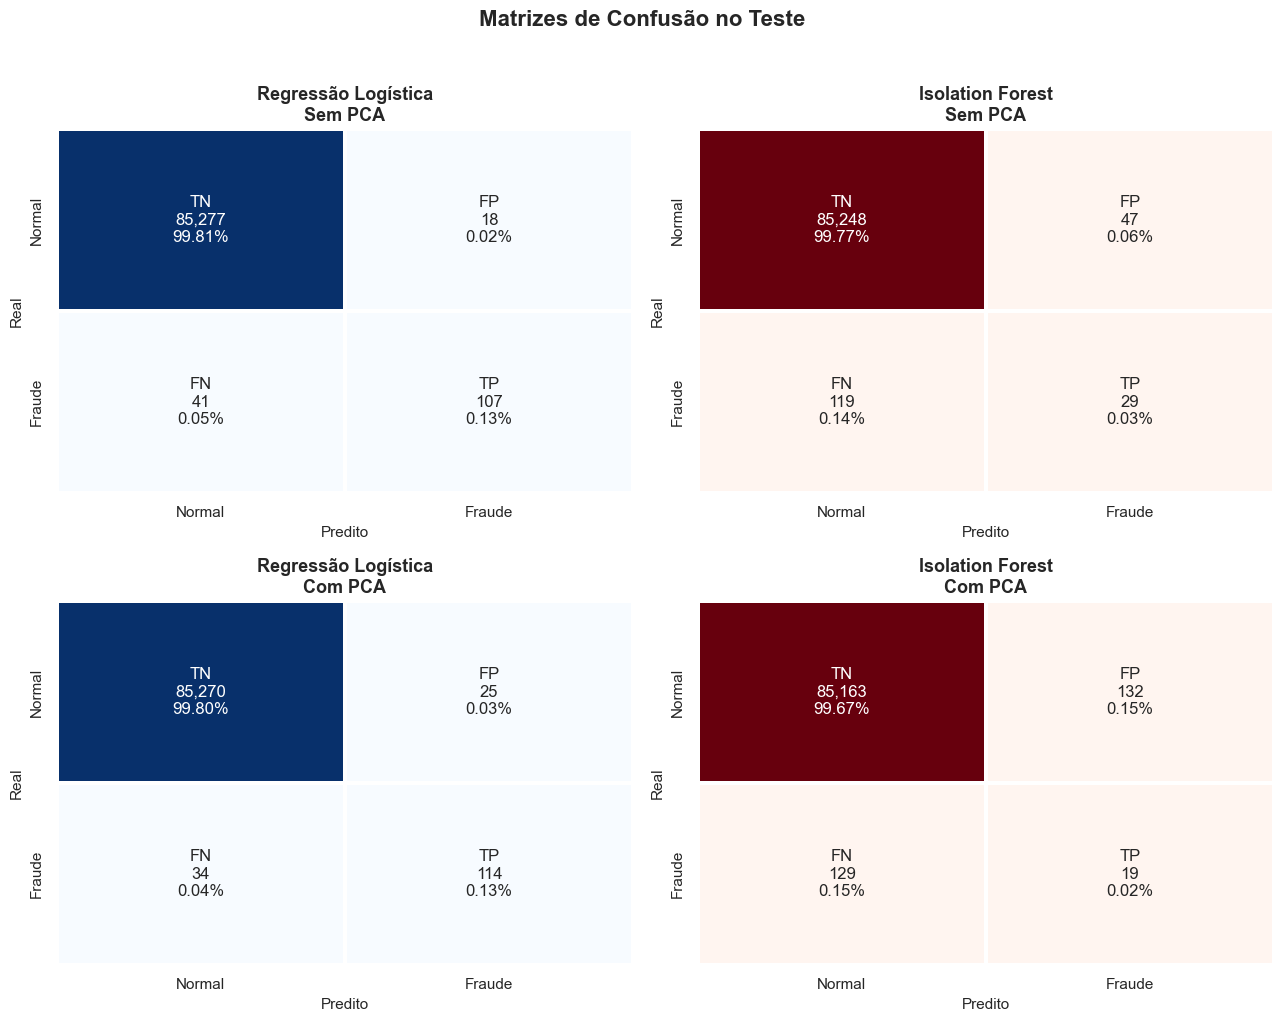

In [20]:
def cm_annotations(cm):
    total = cm.sum()
    return np.array([
        [f'TN\n{cm[0, 0]:,}\n{cm[0, 0] / total:.2%}', f'FP\n{cm[0, 1]:,}\n{cm[0, 1] / total:.2%}'],
        [f'FN\n{cm[1, 0]:,}\n{cm[1, 0] / total:.2%}', f'TP\n{cm[1, 1]:,}\n{cm[1, 1] / total:.2%}'],
    ])

cms = {
    'Regressão Logística\nSem PCA': confusion_matrix(y_test, y_pred_lr_sem_pca, labels=[0, 1]),
    'Isolation Forest\nSem PCA': confusion_matrix(y_test, y_pred_iso_sem_pca, labels=[0, 1]),
    'Regressão Logística\nCom PCA': confusion_matrix(y_test, y_pred_lr_pca, labels=[0, 1]),
    'Isolation Forest\nCom PCA': confusion_matrix(y_test, y_pred_iso_pca, labels=[0, 1]),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (title, cm) in zip(axes.ravel(), cms.items()):
    sns.heatmap(
        cm,
        annot=cm_annotations(cm),
        fmt='',
        cmap='Blues' if 'Regressão' in title else 'Reds',
        cbar=False,
        linewidths=1.5,
        linecolor='white',
        xticklabels=['Normal', 'Fraude'],
        yticklabels=['Normal', 'Fraude'],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

plt.suptitle('Matrizes de Confusão no Teste', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

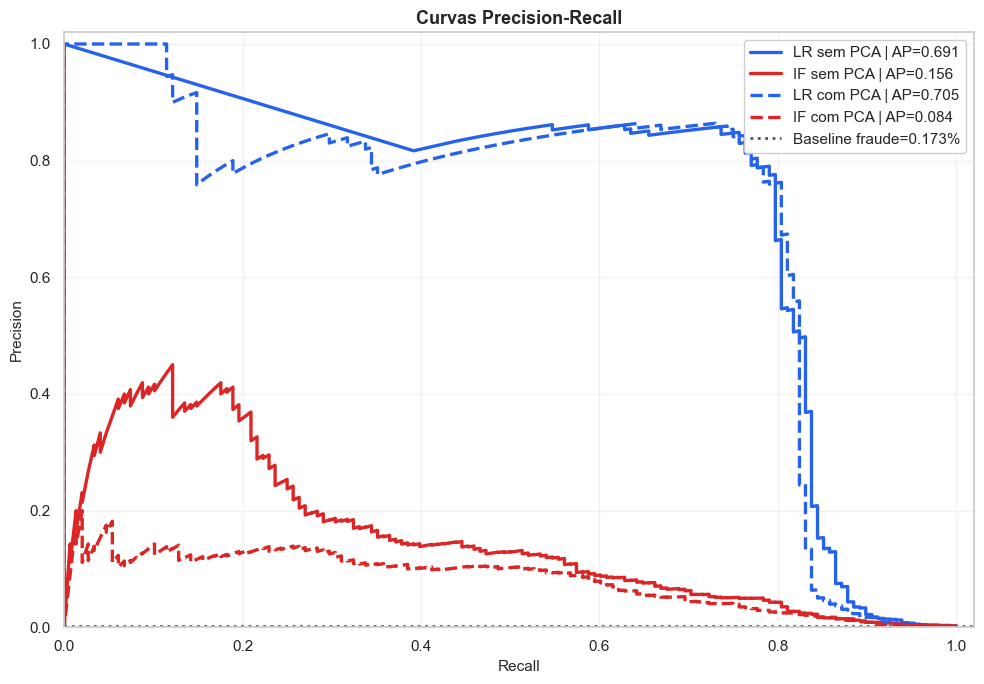

In [21]:
# Curvas Precision-Recall dos melhores modelos
curve_specs = [
    ('LR sem PCA', y_score_lr_sem_pca, PALETTE['lr'], '-'),
    ('IF sem PCA', y_score_iso_sem_pca, PALETTE['if'], '-'),
    ('LR com PCA', y_score_lr_pca, PALETTE['lr'], '--'),
    ('IF com PCA', y_score_iso_pca, PALETTE['if'], '--'),
]

fig, ax = plt.subplots(figsize=(10, 7))
for label, score, color, linestyle in curve_specs:
    precision, recall, _ = precision_recall_curve(y_test, score)
    ap = average_precision_score(y_test, score)
    ax.plot(recall, precision, label=f'{label} | AP={ap:.3f}', color=color, linestyle=linestyle, linewidth=2.4)

ax.axhline(y_test.mean(), color=PALETTE['neutral'], linestyle=':', linewidth=2, label=f'Baseline fraude={y_test.mean():.3%}')
ax.set_title('Curvas Precision-Recall')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.legend(loc='upper right')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

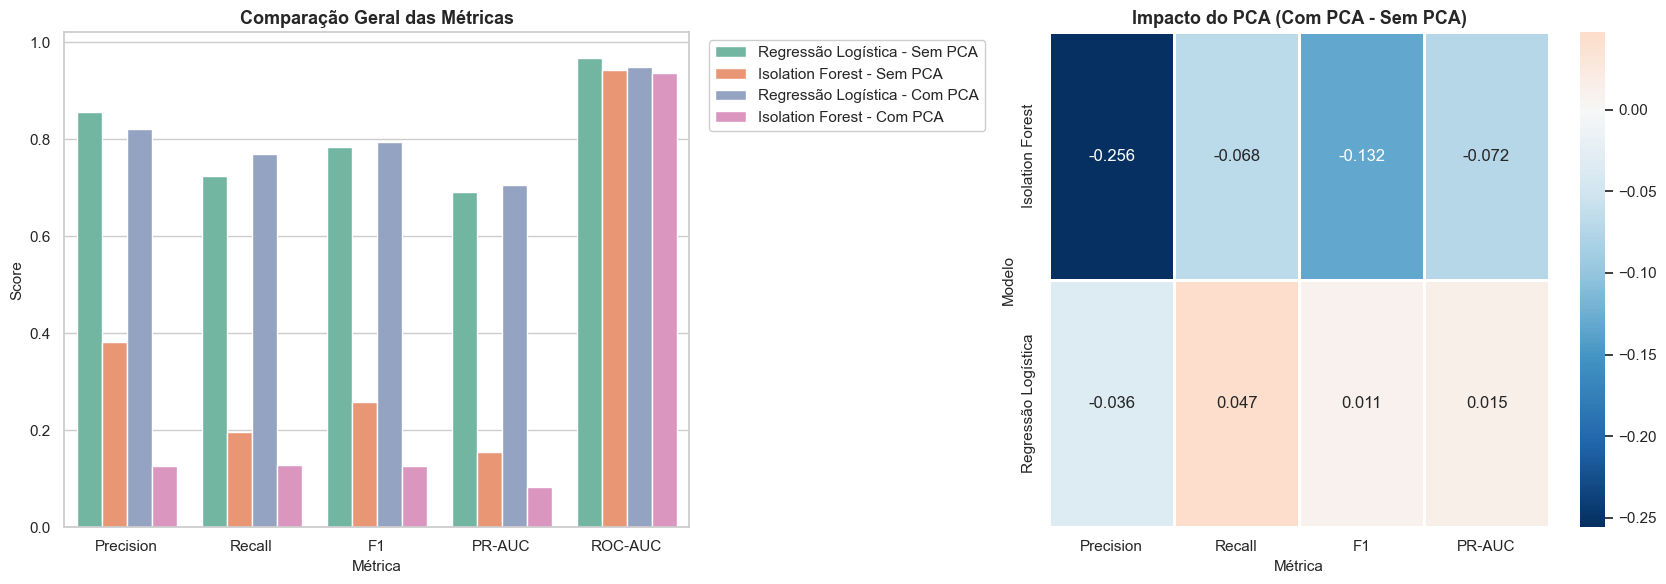

In [22]:
# Comparação de métricas e impacto do PCA
plot_df = resultados.melt(
    id_vars=['Modelo', 'Cenário', 'Método'],
    value_vars=['Precision', 'Recall', 'F1', 'PR-AUC', 'ROC-AUC'],
    var_name='Métrica', value_name='Score'
)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.barplot(
    data=plot_df,
    x='Métrica', y='Score', hue='Método',
    palette='Set2', ax=axes[0]
)
axes[0].set_title('Comparação Geral das Métricas')
axes[0].set_ylim(0, 1.02)
axes[0].legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left')

impacto = resultados.pivot(index='Modelo', columns='Cenário', values=['Precision', 'Recall', 'F1', 'PR-AUC'])
impacto_delta = impacto.xs('Com PCA', axis=1, level=1) - impacto.xs('Sem PCA', axis=1, level=1)
sns.heatmap(
    impacto_delta,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    linewidths=1,
    linecolor='white',
    ax=axes[1]
)
axes[1].set_title('Impacto do PCA (Com PCA - Sem PCA)')
axes[1].set_xlabel('Métrica')
axes[1].set_ylabel('Modelo')

plt.tight_layout()
plt.show()

,Método,FP,FN,TP,TN,FPR,FNR,Recall,Precision,F1
2,Regressão Logística - Com PCA,25,34,114,85270,0.0003,0.2297,0.7703,0.8201,0.7944
0,Regressão Logística - Sem PCA,18,41,107,85277,0.0002,0.2770,0.7230,0.8560,0.7839
1,Isolation Forest - Sem PCA,47,119,29,85248,0.0006,0.8041,0.1959,0.3816,0.2589
3,Isolation Forest - Com PCA,132,129,19,85163,0.0015,0.8716,0.1284,0.1258,0.1271


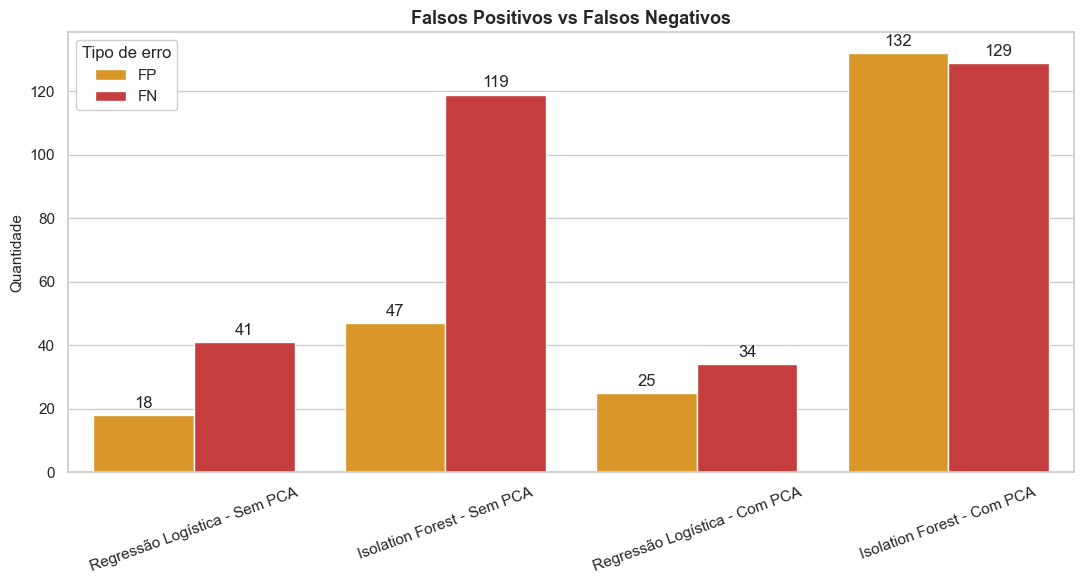

Leitura: FN é o erro mais caro em fraude, pois representa fraude aprovada como normal. FP gera atrito operacional, mas normalmente pode ser revisado.


In [24]:
# Análise focada em falsos positivos e falsos negativos
error_df = resultados[['Método', 'FP', 'FN', 'TP', 'TN', 'FPR', 'FNR', 'Recall', 'Precision', 'F1']].copy()
error_df[['FPR', 'FNR', 'Recall', 'Precision', 'F1']] = error_df[['FPR', 'FNR', 'Recall', 'Precision', 'F1']].round(4)
display(error_df.sort_values(['FN', 'FP']))

fig, ax = plt.subplots(figsize=(11, 6))
error_long = error_df.melt(id_vars='Método', value_vars=['FP', 'FN'], var_name='Tipo de erro', value_name='Quantidade')
sns.barplot(data=error_long, x='Método', y='Quantidade', hue='Tipo de erro', palette=['#f59e0b', '#dc2626'], ax=ax)
ax.set_title('Falsos Positivos vs Falsos Negativos')
ax.set_xlabel('')
ax.set_ylabel('Quantidade')
ax.tick_params(axis='x', rotation=20)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
plt.tight_layout()
plt.show()

print('Leitura: FN é o erro mais caro em fraude, pois representa fraude aprovada como normal. FP gera atrito operacional, mas normalmente pode ser revisado.')

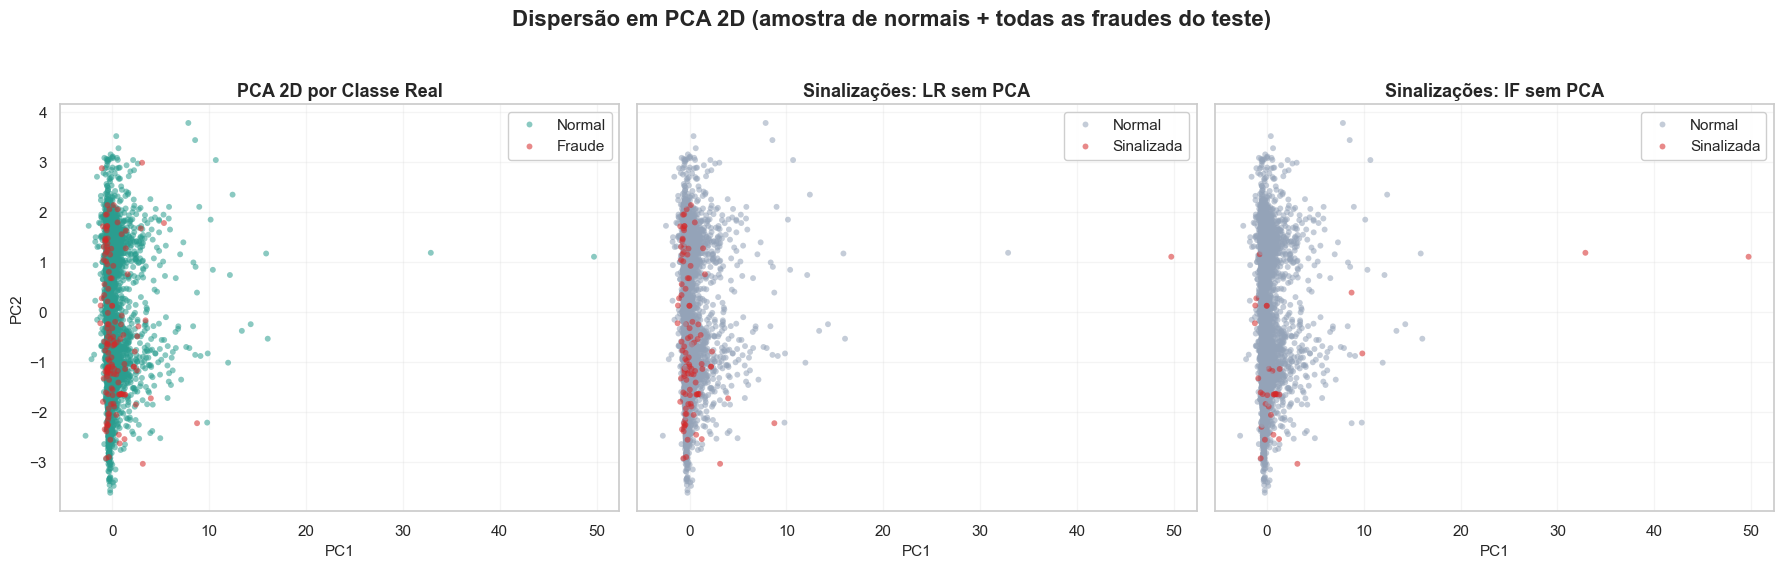

In [25]:
# Dispersão PCA 2D para interpretação visual
rng = np.random.default_rng(RANDOM_STATE)
test_plot = pd.DataFrame(X_test_pca_2d, columns=['PC1', 'PC2'])
test_plot['Classe real'] = np.where(y_test == 1, 'Fraude', 'Normal')
test_plot['LR sem PCA'] = np.where(y_pred_lr_sem_pca == 1, 'Sinalizada', 'Normal')
test_plot['IF sem PCA'] = np.where(y_pred_iso_sem_pca == 1, 'Sinalizada', 'Normal')

normal_idx = test_plot.index[test_plot['Classe real'] == 'Normal'].to_numpy()
fraud_idx = test_plot.index[test_plot['Classe real'] == 'Fraude'].to_numpy()
normal_sample = rng.choice(normal_idx, size=min(6000, len(normal_idx)), replace=False)
plot_idx = np.concatenate([normal_sample, fraud_idx])
plot_sample = test_plot.loc[plot_idx].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharex=True, sharey=True)

sns.scatterplot(
    data=plot_sample, x='PC1', y='PC2', hue='Classe real',
    hue_order=['Normal', 'Fraude'], palette=[PALETTE['normal'], PALETTE['fraude']],
    s=18, alpha=0.55, linewidth=0, ax=axes[0]
)
axes[0].set_title('PCA 2D por Classe Real')

for ax, col, title in [(axes[1], 'LR sem PCA', 'Sinalizações: LR sem PCA'), (axes[2], 'IF sem PCA', 'Sinalizações: IF sem PCA')]:
    sns.scatterplot(
        data=plot_sample, x='PC1', y='PC2', hue=col,
        hue_order=['Normal', 'Sinalizada'], palette=['#94a3b8', PALETTE['fraude']],
        s=18, alpha=0.55, linewidth=0, ax=ax
    )
    ax.set_title(title)

for ax in axes:
    ax.legend(title='', loc='best')
    ax.grid(alpha=0.2)

plt.suptitle('Dispersão em PCA 2D (amostra de normais + todas as fraudes do teste)', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---
## 7. Análise Comparativa e Perguntas Teóricas

In [28]:
# Insights automáticos para apoiar a resposta final
best_row = resultados.sort_values(['F1', 'Recall', 'PR-AUC'], ascending=False).iloc[0]
best_recall_row = resultados.sort_values(['Recall', 'F1', 'PR-AUC'], ascending=False).iloc[0]

print('=' * 90)
print('INSIGHTS FINAIS')
print('=' * 90)

print(f"Melhor equilíbrio por F1: {best_row['Método']} | F1={best_row['F1']:.4f}, Recall={best_row['Recall']:.4f}, Precision={best_row['Precision']:.4f}")
print(f"Maior Recall: {best_recall_row['Método']} | Recall={best_recall_row['Recall']:.4f}, F1={best_recall_row['F1']:.4f}, Precision={best_recall_row['Precision']:.4f}")

print('\n1) Por que o problema é desafiador e acurácia não basta?')
print('- Fraudes são raras; a classe positiva é muito pequena. Um modelo que prevê tudo como normal tem acurácia altíssima, mas recall zero para fraude.')
print('- Métricas como Recall, F1 e PR-AUC são mais informativas porque avaliam diretamente a capacidade de encontrar a classe minoritária.')

print('\n2) Impacto da regularização e do class_weight na Regressão Logística')
print('- L1 pode zerar coeficientes e simplificar o modelo; L2 tende a ser mais estável; ElasticNet combina seleção e estabilidade.')
print("- class_weight='balanced' aumenta o peso da fraude no treinamento, geralmente elevando recall, mas pode reduzir precision por aumentar falsos positivos.")
print('- O threshold foi ajustado em validação para maximizar F1, evitando depender cegamente do corte 0.5.')

print('\n3) Sensibilidade do Isolation Forest')
print('- contamination controla quantos pontos serão tratados como anomalia. Valores baixos reduzem FP, mas podem aumentar FN; valores altos aumentam recall, mas tendem a derrubar precision.')
print('- Como não usa rótulos no ajuste, é útil quando os rótulos são escassos ou incertos, mas pode confundir comportamento raro legítimo com fraude.')

print('\n4) PCA ajudou ou prejudicou?')
for model in resultados['Modelo'].unique():
    sem = resultados[(resultados['Modelo'] == model) & (resultados['Cenário'] == 'Sem PCA')].iloc[0]
    com = resultados[(resultados['Modelo'] == model) & (resultados['Cenário'] == 'Com PCA')].iloc[0]
    print(f"- {model}: F1={com['F1'] - sem['F1']:+.4f}, Recall={com['Recall'] - sem['Recall']:+.4f}, PR-AUC={com['PR-AUC'] - sem['PR-AUC']:+.4f}")
print('- Interprete PCA como troca entre compressão/ruído e perda de informação discriminativa; a decisão depende das métricas no teste.')

print('\n5) Em que cenário usar cada abordagem?')
print('- Regressão Logística: quando há histórico rotulado confiável, necessidade de interpretabilidade e calibragem operacional por threshold.')
print('- Isolation Forest: quando faltam rótulos, quando se deseja triagem inicial de anomalias ou monitoramento de padrões novos.')

print('\n6) É possível combinar os dois métodos?')
print('- Sim. Pode-se usar votação OR para maximizar recall, votação AND para maximizar precision, cascata IF -> LR para triagem e refinamento, ou stacking usando scores de ambos.')

print('\n7) Conexão com outros domínios')
print('- A mesma lógica aparece em cibersegurança, manutenção preditiva, saúde, IoT e controle de qualidade: eventos críticos são raros, labels podem ser incompletos e o custo de FN costuma ser alto.')

INSIGHTS FINAIS
Melhor equil?brio por F1: Regressão Logística - Com PCA | F1=0.7944, Recall=0.7703, Precision=0.8201
Maior Recall: Regressão Logística - Com PCA | Recall=0.7703, F1=0.7944, Precision=0.8201

1) Por que o problema é desafiador e acurácia não basta?
- Fraudes são raras; a classe positiva é muito pequena. Um modelo que prevê tudo como normal tem acurácia altíssima, mas recall zero para fraude.
- Métricas como Recall, F1 e PR-AUC são mais informativas porque avaliam diretamente a capacidade de encontrar a classe minoritária.

2) Impacto da regularização e do class_weight na Regressão Logística
- L1 pode zerar coeficientes e simplificar o modelo; L2 tende a ser mais estável; ElasticNet combina seleção e estabilidade.
- class_weight='balanced' aumenta o peso da fraude no treinamento, geralmente elevando recall, mas pode reduzir precision por aumentar falsos positivos.
- O threshold foi ajustado em valida??o para maximizar F1, evitando depender cegamente do corte 0.5.

3) Sens

In [29]:
# Checklist final da atividade
checklist = pd.DataFrame({
    'Exigência': [
        'EDA com distribuição da variável alvo',
        'Discussão sobre desbalanceamento e acurácia',
        'Regressão Logística: L1, L2 e ElasticNet',
        'Regressão Logística: C = 0.01, 0.1, 1, 10',
        "Regressão Logística: class_weight padrão vs 'balanced'",
        'Isolation Forest: n_estimators = 50, 100, 200',
        'Isolation Forest: contamination = 0.001, true_rate, 0.01, 0.05',
        'Isolation Forest: max_samples variado',
        'Matrizes de confusão claras',
        'Precision-Recall curves',
        'Análise de FP e FN',
        'Comparação rigorosa com e sem PCA',
        'Dispersão PCA 2D',
        'Respostas teóricas finais',
    ],
    'Status': ['OK'] * 14,
})
checklist

,Exigência,Status
0,EDA com distribuição da variável alvo,OK
1,Discussão sobre desbalanceamento e acurácia,OK
2,"Regressão Logística: L1, L2 e ElasticNet",OK
3,"Regressão Logística: C = 0.01, 0.1, 1, 10",OK
4,Regressão Logística: class_weight padrão vs 'b...,OK
5,"Isolation Forest: n_estimators = 50, 100, 200",OK
6,"Isolation Forest: contamination = 0.001, true_...",OK
7,Isolation Forest: max_samples variado,OK
8,Matrizes de confusão claras,OK
9,Precision-Recall curves,OK
